In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
from scipy.sparse import csr_matrix
from sklearn.linear_model import LinearRegression
import pandas as pd
# Загрузка данных
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [3]:
# Преобразование разреженной матрицы из строкового представления
#def convert_to_sparse(data):
#    for column in data.select_dtypes(include=['object']):
#        data[column] = data[column].map(lambda x: eval(x) if isinstance(x, str) else x)
#    return csr_matrix(data.values)  # Преобразование в разреженную матрицу

#X_train = convert_to_sparse(X_train)
#X_test = convert_to_sparse(X_test)

In [4]:
# Шаг 1: Построение модели линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [5]:
# Шаг 2: Предсказание на тестовых данных
y_pred = model.predict(X_test)

In [6]:
# Шаг 3: Оценка модели
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Вывод метрик
print("Метрики модели линейной регрессии:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")

Метрики модели линейной регрессии:
Mean Absolute Error (MAE): 3.2030631094449458
Mean Squared Error (MSE): 18.03287448841637
R² Score: 0.805760973419041


In [7]:
import json

# Пример метрик
metrics = {
    "MAE": mae,
    "MSE": mse,
    "R2": r2
}

# Сохранение метрик в файл
with open(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\metrics\redline_metrics.json", "w") as f:
    json.dump(metrics, f)

In [8]:
import pickle

with open(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\redline_model.pkl", "wb") as f:
    pickle.dump(model, f)

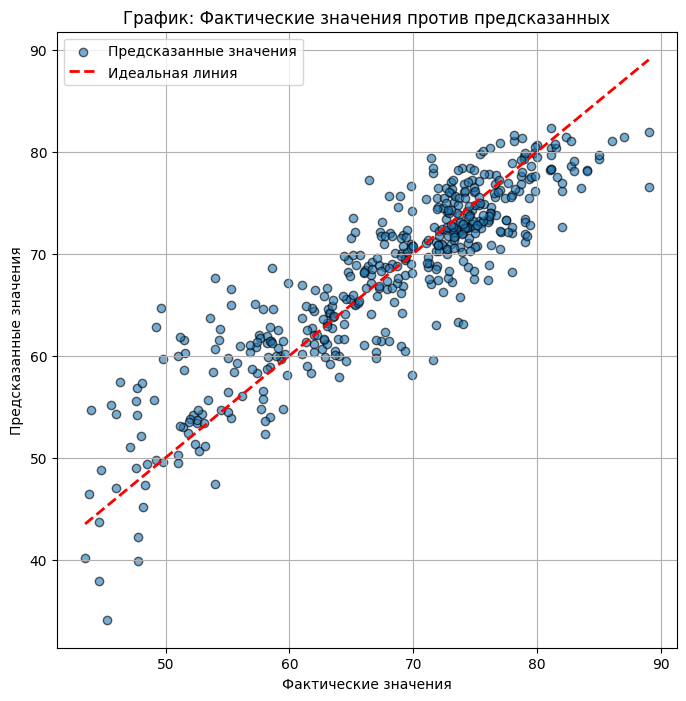

In [9]:
# Построение графика "Фактические значения против предсказанных"
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k', label="Предсказанные значения")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Идеальная линия")
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("График: Фактические значения против предсказанных")
plt.legend()
plt.grid(True)

plt.savefig(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\redline\1.png", dpi=300, bbox_inches="tight")

plt.show()

